In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 12000/12000 [00:00<00:00, 261736.40it/s]


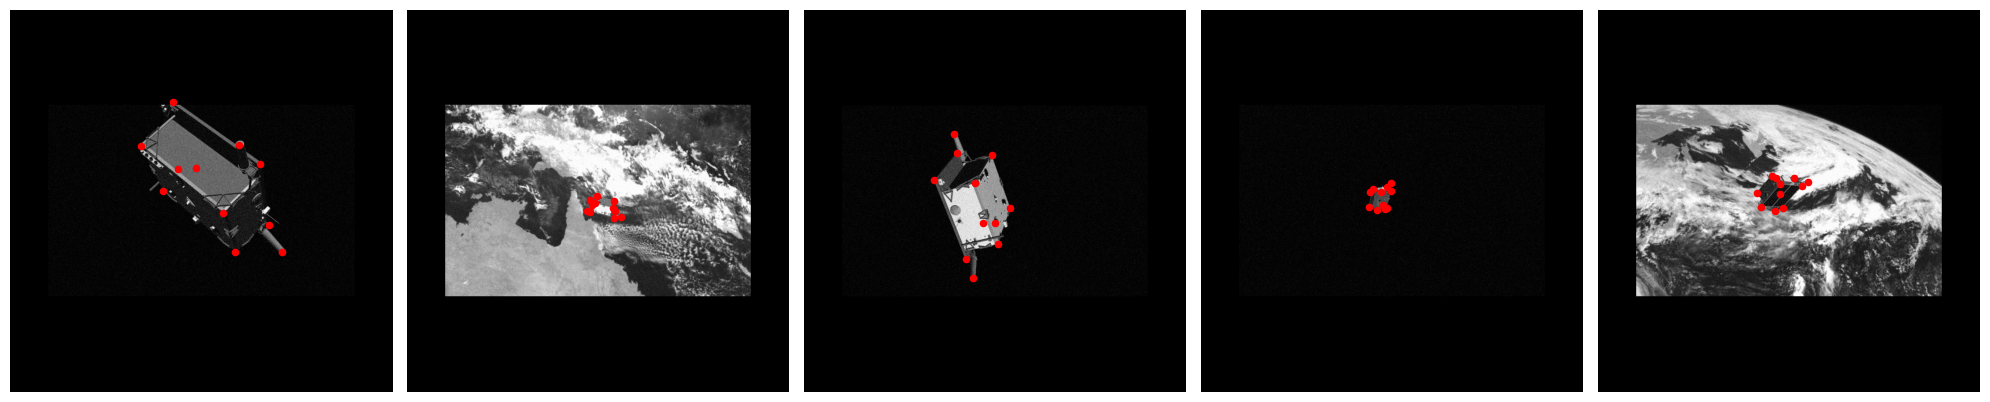

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


Layer (type:depth-idx)                        Output Shape              Param #
ApproachZero                                  [1, 22, 1, 1]             2,049,000
├─Sequential: 1-1                             [1, 2048, 7, 7]           --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
│    └─Sequential: 2-5                        [1, 256, 56, 56]          --
│    │    └─Bottleneck: 3-1                   [1, 256, 56, 56]          75,008
│    │    └─Bottleneck: 3-2                   [1, 256, 56, 56]          70,400
│    │    └─Bottleneck: 3-3                   [1, 256, 56, 56]          70,400
│    └─Sequential: 2-6                        [1, 512, 28, 28]          --
│    │    └─Bottleneck: 3-4                   [1, 512, 28, 28]          

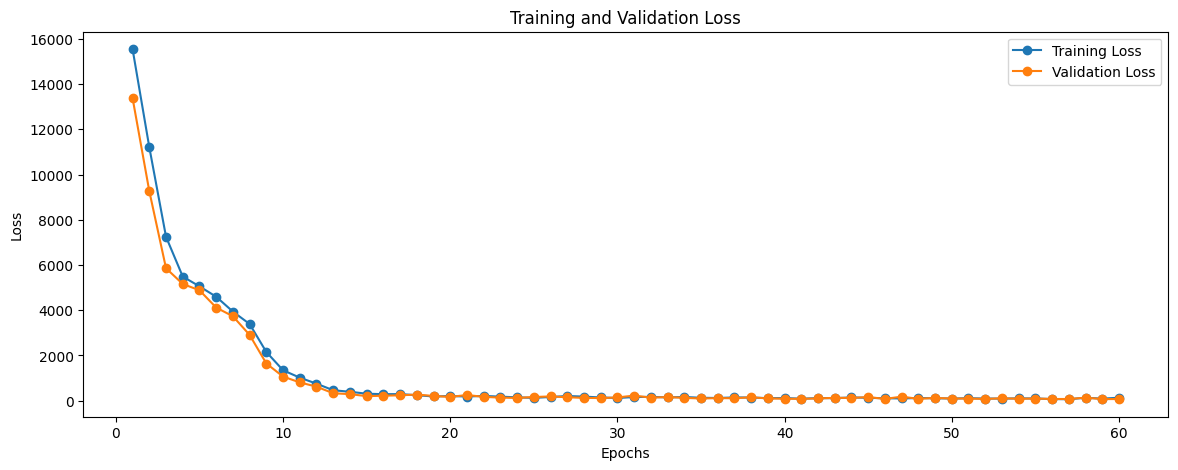

In [ ]:
import os
import json
from torch.utils.data import Dataset, DataLoader
import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from torchvision import transforms
# Removed import of torchvision.transforms.functional as TF since using F.interpolate
from scipy.io import loadmat
import cv2
from ultralytics import YOLO
from PIL import Image
from torch import nn, optim
from torchinfo import summary
import torchvision
import torch.backends.cudnn as cudnn
import torch.nn.functional as F
import torch.amp as amp
from torchvision.ops import roi_align

class SPEEDDataset(Dataset):
    def __init__(self, images_dir, json_dir, tango_points_dir, camera_matrix_dir, transform=None, is_train=True):
        self.image_width = 1920
        self.image_height = 1200
        self.aspect_ratio = self.image_width * 1.0 / self.image_height
        self.pixel_std = 200
        self.num_joints = 11
        self.image_size = [640, 640]
        self.scale_factor = 0.25
        self.rotation_factor = 30
        self.sigma = 2
        self.is_train = is_train
        self.transform = transform

        self.imagesList = []
        self.frameInfoList = []
        self.images_dir = images_dir
        self.json_dir = json_dir

        self.keypts3d = self.load_tango_3d_keypoints(tango_points_dir) # https://www.desmos.com/3d/jud6lng9gn
        self.cameraMatrix, self.distCoeffs = self.load_camera_intrinsics(camera_matrix_dir)

        with open(self.json_dir, 'r') as f:
            annotations = json.load(f)
            lookup = { item['filename']: item for item in annotations }
            cnt = 0
            for filename in tqdm.tqdm(sorted(os.listdir(self.images_dir))):
                if filename not in lookup:
                    continue
                frame_idx = int(''.join(filter(str.isdigit, filename.split('.')[0])))
                self.imagesList.append(os.path.join(self.images_dir, filename))

                q_vbs2tango = np.array(lookup[filename]["q_vbs2tango"], dtype=np.float32)
                r_Vo2To_vbs = np.array(lookup[filename]['r_Vo2To_vbs_true'], dtype=np.float32)

                frame_info = {
                    'filename': filename,
                    'q_vbs2tango': q_vbs2tango,
                    'r_Vo2To_vbs': r_Vo2To_vbs
                }
                self.frameInfoList.append(frame_info)

                cnt = cnt + 1
                # if cnt>20:
                #     break

    def __len__(self):
        return len(self.imagesList)

    def quat2dcm(self, q):
        """ Computing direction cosine matrix from quaternion, adapted from PyNav.
        Arguments:
            q: (4,) numpy.ndarray - unit quaternion (scalar-first)
        Returns:
            dcm: (3,3) numpy.ndarray - corresponding DCM
        """

        # normalizing quaternion
        q = q / np.linalg.norm(q)

        q0, q1, q2, q3 = q[0], q[1], q[2], q[3]
        dcm = np.zeros((3, 3))
        dcm[0, 0] = 2 * q0 ** 2 - 1 + 2 * q1 ** 2
        dcm[1, 1] = 2 * q0 ** 2 - 1 + 2 * q2 ** 2
        dcm[2, 2] = 2 * q0 ** 2 - 1 + 2 * q3 ** 2
        dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
        dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2
        dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
        dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1
        dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
        dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1

        return dcm

    def load_tango_3d_keypoints(self, mat_dir):
        vertices = loadmat(mat_dir)['tango3Dpoints']
        corners3D = np.transpose(np.array(vertices, dtype=np.float32))
        return corners3D

    def load_camera_intrinsics(self, camera_json):
        with open(camera_json) as f:
            cam = json.load(f)
        cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
        distCoeffs = np.array(cam['distCoeffs'], dtype=np.float32)
        return cameraMatrix, distCoeffs

    def project_keypoints(self, q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
        if keypoints.shape[0] != 3:
            keypoints = np.transpose(keypoints)
        keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))
        pose_mat = np.hstack((np.transpose(self.quat2dcm(q_vbs2tango)),
                              np.expand_dims(r_Vo2To_vbs, 1)))
        xyz = np.dot(pose_mat, keypoints)
        x0, y0 = xyz[0, :] / xyz[2, :], xyz[1, :] / xyz[2, :]
        r2 = x0 * x0 + y0 * y0
        cdist = 1 + distCoeffs[0] * r2 + distCoeffs[1] * r2 * r2 + distCoeffs[4] * r2 * r2 * r2
        x = x0 * cdist + distCoeffs[2] * 2 * x0 * y0 + distCoeffs[3] * (r2 + 2 * x0 * x0)
        y = y0 * cdist + distCoeffs[2] * (r2 + 2 * y0 * y0) + distCoeffs[3] * 2 * x0 * y0
        points2D = np.vstack((cameraMatrix[0, 0] * x + cameraMatrix[0, 2],
                              cameraMatrix[1, 1] * y + cameraMatrix[1, 2]))
        return points2D

    def _box2cs(self, box):
        x, y, w, h = box[:4]
        return self._xywh2cs(x, y, w, h)

    def _xywh2cs(self, x, y, w, h):
        center = np.zeros((2), dtype=np.float32)
        center[0] = x + w * 0.5
        center[1] = y + h * 0.5

        if w > self.aspect_ratio * h:
            h = w * 1.0 / self.aspect_ratio
        elif w < self.aspect_ratio * h:
            w = h * self.aspect_ratio
        scale = np.array(
            [w * 1.0 / self.pixel_std, h * 1.0 / self.pixel_std],
            dtype=np.float32)
        if center[0] != -1:
            scale = scale * 1.25

        return center, scale

    def get_affine_transform(self, center, scale, rot, output_size, shift=np.array([0, 0], dtype=np.float32), inv=0):
        if not isinstance(scale, np.ndarray) and not isinstance(scale, list):
            scale = np.array([scale, scale])
        scale_tmp = scale * 200.0
        src_w = scale_tmp[0]
        dst_w = output_size[0]
        dst_h = output_size[1]
        rot_rad = np.pi * rot / 180
        src_dir = self.get_dir([0, src_w * -0.5], rot_rad)
        dst_dir = np.array([0, dst_w * -0.5], np.float32)
        src = np.zeros((3, 2), dtype=np.float32)
        dst = np.zeros((3, 2), dtype=np.float32)
        src[0, :] = center + scale_tmp * shift
        src[1, :] = center + src_dir + scale_tmp * shift
        dst[0, :] = [dst_w * 0.5, dst_h * 0.5]
        dst[1, :] = np.array([dst_w * 0.5, dst_h * 0.5]) + dst_dir
        src[2:, :] = self.get_3rd_point(src[0, :], src[1, :])
        dst[2:, :] = self.get_3rd_point(dst[0, :], dst[1, :])
        if inv:
            trans = cv2.getAffineTransform(np.float32(dst), np.float32(src))
        else:
            trans = cv2.getAffineTransform(np.float32(src), np.float32(dst))
        return trans

    def affine_transform(self, pt, t):
        new_pt = np.array([pt[0], pt[1], 1.]).T
        new_pt = np.dot(t, new_pt)
        return new_pt[:2]

    def get_3rd_point(self, a, b):
        direct = a - b
        return b + np.array([-direct[1], direct[0]], dtype=np.float32)

    def get_dir(self, src_point, rot_rad):
        sn, cs = np.sin(rot_rad), np.cos(rot_rad)
        src_result = [0, 0]
        src_result[0] = src_point[0] * cs - src_point[1] * sn
        src_result[1] = src_point[0] * sn + src_point[1] * cs
        return src_result

    def __getitem__(self, idx):
        image_path = self.imagesList[idx]
        data_numpy = cv2.imread(image_path, cv2.IMREAD_COLOR | cv2.IMREAD_IGNORE_ORIENTATION)
        data_numpy = cv2.cvtColor(data_numpy, cv2.COLOR_BGR2RGB)

        q_vbs2tango = self.frameInfoList[idx]['q_vbs2tango']
        r_Vo2To_vbs = self.frameInfoList[idx]['r_Vo2To_vbs']

        keypts2d = self.project_keypoints(q_vbs2tango, r_Vo2To_vbs,
                                          self.cameraMatrix, self.distCoeffs,
                                          self.keypts3d)  # (2, 11)

        box_full = [0, 0, self.image_width, self.image_height]

        c_full, s_full = self._box2cs(box_full)
        r_full = 0

        if self.is_train:
            sf = self.scale_factor
            rf = self.rotation_factor
            s_full = s_full * np.clip(np.random.randn()*sf + 1, 1 - sf, 1 + sf)
            r_full = np.clip(np.random.randn()*rf, -rf*2, rf*2) \
                    if random.random() <= 0.6 else 0

        trans_full = self.get_affine_transform(c_full, s_full, r_full, self.image_size)

        wrappedImage_full = cv2.warpAffine(
            data_numpy,
            trans_full,
            (int(self.image_size[0]), int(self.image_size[1])),
            flags=cv2.INTER_LINEAR)

        keypts = np.zeros_like(keypts2d)
        for i in range(keypts2d.shape[1]):
            keypts[:, i] = self.affine_transform(keypts2d[:, i], trans_full)

        xmin = float(np.min(keypts[0]))
        xmax = float(np.max(keypts[0]))
        ymin = float(np.min(keypts[1]))
        ymax = float(np.max(keypts[1]))

        xmin = max(0.0, xmin)
        ymin = max(0.0, ymin)
        xmax = min(self.image_size[0], xmax)
        ymax = min(self.image_size[1], ymax)

        w = xmax - xmin
        h = ymax - ymin
        margin_w = 0.05 * w
        margin_h = 0.05 * h
        xmin = max(0.0, xmin - margin_w)
        ymin = max(0.0, ymin - margin_h)
        xmax = min(self.image_size[0], xmax + margin_w)
        ymax = min(self.image_size[1], ymax + margin_h)

        if self.transform:
            wrappedImage_full = self.transform(wrappedImage_full)

        boxTorch = torch.tensor([xmin, ymin, xmax - xmin, ymax - ymin], dtype=torch.float32)
        keypts = torch.tensor(keypts, dtype=torch.float32)

        return wrappedImage_full, keypts


train_transforms = transforms.Compose([
    # transforms.ToPILImage(),
    # transforms.ColorJitter(brightness=1, contrast=1, saturation=1, hue=0.1),
    transforms.ToTensor(),
    # transforms.Normalize(
    #     mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    # )
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(
    #     mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    # )
])

train_dataset = SPEEDDataset(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', tango_points_dir='/kaggle/input/mat-file/tangoPoints.mat', camera_matrix_dir='/kaggle/input/mat-file/camera.json', transform=train_transforms, is_train=True)
val_dataset = SPEEDDataset(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', tango_points_dir='/kaggle/input/mat-file/tangoPoints.mat', camera_matrix_dir='/kaggle/input/mat-file/camera.json', transform=val_transforms, is_train = False)

dataset_size = len(train_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

seed = 42
indices = list(range(dataset_size))
random.Random(seed).shuffle(indices)
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_data = torch.utils.data.Subset(train_dataset, train_indices)
val_data = torch.utils.data.Subset(val_dataset, val_indices)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    image, keypts = val_data[i]
    img = image.permute(1, 2, 0).cpu().numpy()
    keypts_np = keypts.cpu().numpy()
    ax = axes[i]
    ax.imshow(img)
    ax.scatter(keypts_np[0, :], keypts_np[1, :], c='r', s=20)
    ax.axis('off')

plt.tight_layout()
plt.show()

class ApproachZero(nn.Module):
    def __init__(self):
        super().__init__()

        self.num_joints = 11

        self.resnet50 = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)
        self.resnet50Features = nn.Sequential(*list(self.resnet50.children())[:-2])
        # Running features [B, 2048, 7, 7]

        self.conv1 = nn.Conv2d(2048, 512, kernel_size=1)
        self.bn1   = nn.BatchNorm2d(512)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(512, 2 * self.num_joints, kernel_size=1)

        self.conv3 = nn.Conv2d(2 * self.num_joints, 2 * self.num_joints, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(2 * self.num_joints)

        self.conv4 = nn.Conv2d(2 * self.num_joints, 2 * self.num_joints, kernel_size=3, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(2 * self.num_joints)

        self.conv5 = nn.Conv2d(2 * self.num_joints, 2 * self.num_joints, kernel_size=2, stride=2)

    def forward(self, X, targets=None):
        feats = self.resnet50Features(X)
        x = self.conv1(feats)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu(x)

        x = self.conv5(x)
        x = self.relu(x)

        return x

def train_loop(train_dataloader,val_dataloader,modelODN, model,loss_fn,optimizer,batch_size,epoch,scaler):
    train_size = len(train_dataloader.dataset)
    num_batches = len(train_dataloader)
    loss_tot = 0
    for batch,(X, Y_keypts) in enumerate(train_dataloader):
        X, Y_keypts = X.to(device), Y_keypts.to(device)
        YOLO_output= modelODN(X, verbose=False)

        # handle images with no detections by using the full image as ROI
        boxes_list = []
        for out in YOLO_output:
            if out.boxes.xyxy.shape[0] > 0:
                boxes_list.append(out.boxes.xyxy[0])
            else:
                _, _, h, w = X.shape
                boxes_list.append(torch.tensor([0., 0., w, h], device=X.device))
        boxes = torch.stack(boxes_list, dim=0)                                          # [B,4]
        batch_idx = torch.arange(X.size(0), device=boxes.device).unsqueeze(1).float() # [B,1]
        rois = torch.cat([batch_idx, boxes], dim=1)                                   # [B,5]
        crops = roi_align(X, rois, output_size=(224,224), spatial_scale=1.0)          # [B,C,224,224]

        kp = Y_keypts.clone()                                                         # [B,2,J]
        top_left = boxes[:, :2].unsqueeze(2)                                          # [B,2,1]
        wh = (boxes[:, 2:] - boxes[:, :2]).unsqueeze(2)                               # [B,2,1]
        Y_scaled = (kp - top_left) * (224.0 / wh)                                     # [B,2,J]

        X_cropped = crops
        Y_keypts = Y_scaled.to(device)

        model.train()
        optimizer.zero_grad()

        with amp.autocast('cuda'):
            pred_keypts = model(X_cropped)
            pred_keypts = pred_keypts.reshape(X_cropped.shape[0], 2 * model.num_joints)
            Y_keypts_flattened = Y_keypts.reshape(X_cropped.shape[0], 2 * model.num_joints)
            loss_keypts = loss_fn(pred_keypts, Y_keypts_flattened)
            loss = loss_keypts
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_tot += loss.item()
        current = batch * batch_size + len(X)
        print(f"\rEpoch {epoch+1} : Training loss: {loss:>10.9f}  [{current:>5d}/{train_size:>5d}]", end="")

    scheduler.step()
    loss_avg = loss_tot / num_batches
    val_loss = 0
    model.eval()
    with torch.no_grad():
        for batch, (X, Y_keypts) in enumerate(val_dataloader):
            X, Y_keypts = X.to(device), Y_keypts.to(device)
            YOLO_output = modelODN(X, verbose=False)

            # same fallback for validation
            boxes_list = []
            for out in YOLO_output:
                if out.boxes.xyxy.shape[0] > 0:
                    boxes_list.append(out.boxes.xyxy[0])
                else:
                    _, _, h, w = X.shape
                    boxes_list.append(torch.tensor([0., 0., w, h], device=X.device))
            boxes = torch.stack(boxes_list, dim=0)                                    # [B,4]
            batch_idx = torch.arange(X.size(0), device=boxes.device).unsqueeze(1).float()
            rois      = torch.cat([batch_idx, boxes], dim=1)                             # [B,5]
            X_cropped = roi_align(X, rois, output_size=(224,224), spatial_scale=1.0)      # [B,C,224,224]

            # vectorized keypoint scaling
            kp       = Y_keypts.clone()                                                   # [B,2,J]
            top_left = boxes[:, :2].unsqueeze(2)                                          # [B,2,1]
            wh       = (boxes[:, 2:] - boxes[:, :2]).unsqueeze(2)                         # [B,2,1]
            Y_keypts = ((kp - top_left) * (224.0 / wh)).to(device)                        # [B,2,J]

            with amp.autocast('cuda'):
                pred_keypts = model(X_cropped)
                pred_keypts = pred_keypts.reshape(X_cropped.shape[0], 2 * model.num_joints)
                Y_keypts_flattened = Y_keypts.reshape(X_cropped.shape[0], 2 * model.num_joints)
                loss_keypts = loss_fn(pred_keypts, Y_keypts_flattened)
                loss = loss_keypts
                val_loss += loss.item()
            current = batch * batch_size + len(X)
            print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>10.9f} - Validation loss: {loss:>10.9f}  [{current:>5d}/{len(val_dataloader.dataset):>5d}]", end="")

    val_loss /= len(val_dataloader)
    print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>10.9f} - Validation loss: {val_loss:>10.9f}                                                    ")
    print(end='')
    return loss_avg, val_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.enabled = True

modelODN = YOLO("/kaggle/input/yolospeed/runs/detect/train/weights/best.pt").to(device)
model = ApproachZero().to(device)

# if torch.cuda.device_count() > 1:
#     print(f"Using {torch.cuda.device_count()} GPUs for ApproachZero")
#     model = nn.DataParallel(model, device_ids=[0,1]).to(device)

learning_rate = 1e-3
batch_size = 32
num_of_epochs = 60
loss_fn = nn.MSELoss()
input_dir = '/kaggle/input/YOLOExtend'
output_dir = '/kaggle/working/'

best_perf = 0.0
best_model = False
last_epoch = -1
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
scaler = amp.GradScaler('cuda')
begin_epoch = 0
checkpoint_file = os.path.join(input_dir, 'checkpoint.pth')

def save_checkpoint(states, is_best, output_dir,
                    filename='checkpoint.pth'):
    torch.save(states, os.path.join(output_dir, filename))
    if is_best and 'state_dict' in states:
        torch.save(states['best_state_dict'],
                   os.path.join(output_dir, 'model_best.pth'))

if os.path.isfile(checkpoint_file):
    checkpoint = torch.load(checkpoint_file, weights_only=False)
    begin_epoch = checkpoint['epoch']
    best_perf = checkpoint['perf']
    last_epoch = checkpoint['epoch']
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    print(f"Loaded checkpoint : {checkpoint_file} at epoch {begin_epoch}")


scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, [120,170], 0.1, last_epoch=last_epoch)

train_dataloader = DataLoader(train_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)
validation_dataloader = DataLoader(val_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)

print(summary(model, (1,3,224,224)))

loss_history = {'train': [], 'val': []}

best_val_loss = float('inf')

for t in range(begin_epoch, begin_epoch + num_of_epochs):
    print(f"Epoch {t+1}", end=" ")
    train_loss, val_loss = train_loop(train_dataloader, validation_dataloader, modelODN, model, loss_fn, optimizer, batch_size, t, scaler)
    loss_history['train'].append(float(train_loss))
    loss_history['val'].append(float(val_loss))

    if (t + 1) % 1 == 0:
        save_checkpoint({
            'epoch': t + 1,
            'model': "PoseHighResolutionNet",
            'state_dict': model.state_dict(),
            'best_state_dict': model.state_dict(),
            'perf': val_loss,
            'optimizer': optimizer.state_dict(),
        }, True, output_dir)


plt.figure(figsize=(14, 5))
eplist=[]
for i in range(begin_epoch, begin_epoch + num_of_epochs):
    eplist.append(i+1)
plt.plot(eplist, loss_history['train'], 'o-', label='Training Loss')
plt.plot(eplist, loss_history['val'], 'o-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()